Bias and Proxy Discrimination in Automated Resume Screening Systems
USC DSCI — Course Project
Authors: Bhalgat, Solanki, Mohnalkar

Pipeline:
  1. Load & preprocess Kaggle resume dataset
  2. Inject synthetic demographic attributes + proxy correlations
  3. Generate biased hiring labels (gamma controls bias magnitude)
  4. Train baseline classifiers (LR, RF)
  5. Evaluate fairness metrics (DP, EO, EqOdds, PP)
  6. Proxy analysis (remove explicit demo features, re-evaluate)
  7. Bias mitigation (pre/in/post-processing)
  8. Trade-off analysis + plots

Requirements:
    pip install pandas numpy scikit-learn fairlearn aif360 matplotlib seaborn pdfplumber
    Dataset: folder-based, structured as data/<RoleName>/*.pdf

In [6]:
!pip install "scipy==1.15.3" "scikit-learn==1.6.1" "fairlearn==0.13.0"

  Using cached scipy-1.15.3-cp313-cp313-macosx_14_0_arm64.whl.metadata (61 kB)
Using cached scipy-1.15.3-cp313-cp313-macosx_14_0_arm64.whl (22.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 50.1 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1.17.1
    Uninstalling scipy-1.17.1:
      Successfully uninstalled scipy-1.17.1
  Attempting uninstall: scikit-learn━━━━━━━━━━━━ 0/2 [scipy]
    Found existing installation: scikit-learn 1.8.032m0/2 [scipy]
    Uninstalling scikit-learn-1.8.0:━━━━━━━━ 0/2 [scipy]
      Successfully uninstalled scikit-learn-1.8.00/2 [scipy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scikit-learn] [scikit-learn]


In [18]:
# ─────────────────────────────────────────────
# CELL 1 — Imports
# ─────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse
import scipy.sparse.linalg  # force load before sklearn

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)
from fairlearn.metrics import (
    demographic_parity_difference, equalized_odds_difference,
    MetricFrame, selection_rate, true_positive_rate, false_positive_rate,
)
from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from fairlearn.postprocessing import ThresholdOptimizer
import warnings; warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
os.makedirs("figures", exist_ok=True)
print("Imports OK")

Imports OK


In [2]:
!pip install pdfplumber

  Using cached cffi-2.0.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 26.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 29.5 MB/s  0:00:00 eta 0:00:01
Using cached cffi-2.0.0-cp313-cp313-macosx_11_0_arm64.whl (181 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 19.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [pdfplumber]7 [pdfminer.six]


In [19]:
# ─────────────────────────────────────────────
# CELL 2 — Load & Preprocess PDFs
# ─────────────────────────────────────────────
import pdfplumber
from pathlib import Path

def load_and_preprocess(data_dir="data"):
    records = []
    data_path = Path(data_dir)
    for role_dir in sorted(data_path.iterdir()):
        if not role_dir.is_dir():
            continue
        category = role_dir.name
        pdf_files = list(role_dir.glob("*.pdf"))
        print(f"  {category}: {len(pdf_files)} PDFs")
        for pdf_path in pdf_files:
            try:
                with pdfplumber.open(pdf_path) as pdf:
                    text = " ".join(page.extract_text() or "" for page in pdf.pages)
                if text.strip():
                    records.append({"text": text, "category": category})
            except Exception as e:
                print(f"    Skipping {pdf_path.name}: {e}")
    df = pd.DataFrame(records)
    df["text"] = df["text"].str.lower().str.replace(r"[^a-z\s]", " ", regex=True)
    print(f"\nLoaded {len(df)} resumes across {df['category'].nunique()} categories.")
    return df

df = load_and_preprocess("data")

  ACCOUNTANT: 118 PDFs
  ADVOCATE: 118 PDFs
  AGRICULTURE: 63 PDFs
  APPAREL: 97 PDFs
  ARTS: 103 PDFs
  AUTOMOBILE: 36 PDFs
  AVIATION: 117 PDFs
  BANKING: 115 PDFs
  BPO: 22 PDFs
  BUSINESS-DEVELOPMENT: 120 PDFs
  CHEF: 118 PDFs
  CONSTRUCTION: 112 PDFs
  CONSULTANT: 115 PDFs
  DESIGNER: 107 PDFs
  DIGITAL-MEDIA: 96 PDFs
  ENGINEERING: 118 PDFs
  FINANCE: 118 PDFs
  FITNESS: 117 PDFs
  HEALTHCARE: 115 PDFs
  HR: 110 PDFs
  INFORMATION-TECHNOLOGY: 120 PDFs
  PUBLIC-RELATIONS: 111 PDFs
  SALES: 116 PDFs
  TEACHER: 102 PDFs

Loaded 2483 resumes across 24 categories.


In [38]:
# ─────────────────────────────────────────────
# CELL 3 — TF-IDF Feature Extraction
# ─────────────────────────────────────────────
def build_features(df, max_features=5000):
    vectorizer = TfidfVectorizer(max_features=max_features,
                                 stop_words="english", ngram_range=(1, 2))
    X_tfidf = vectorizer.fit_transform(df["text"]).toarray()
    proxy_raw = np.random.normal(0, 1, len(df))
    X = np.hstack([X_tfidf, proxy_raw.reshape(-1, 1)])
    print(f"Feature matrix shape: {X.shape}")
    return X, proxy_raw, vectorizer

X, proxy_raw, vectorizer = build_features(df)

Feature matrix shape: (2483, 5001)


In [21]:
# ─────────────────────────────────────────────
# CELL 4 — Demographic Injection + Label Generation
# ─────────────────────────────────────────────
def inject_demographics(X, proxy_raw, pi=0.5, gamma=1.5, proxy_correlation=0.7):
    n = len(X)
    A = np.random.binomial(1, pi, n)
    proxy_correlated = (proxy_correlation * (2 * A - 1)
                        + np.sqrt(1 - proxy_correlation**2) * proxy_raw)
    X[:, -1] = proxy_correlated

    svd = TruncatedSVD(n_components=50, random_state=RANDOM_STATE)
    Xq_reduced = svd.fit_transform(X[:, :-1])
    Xq_score = Xq_reduced[:, :5].mean(axis=1)
    Xq_score = (Xq_score - Xq_score.mean()) / (Xq_score.std() + 1e-8)

    logits = 2.0 * Xq_score + gamma * A
    probs = 1 / (1 + np.exp(-logits))
    Y = np.random.binomial(1, probs)

    print(f"Group A=0 selection rate: {Y[A==0].mean():.3f}")
    print(f"Group A=1 selection rate: {Y[A==1].mean():.3f}")
    print(f"Overall positive rate:    {Y.mean():.3f}")
    return X, A, Y

X, A, Y = inject_demographics(X, proxy_raw)

Group A=0 selection rate: 0.522
Group A=1 selection rate: 0.726
Overall positive rate:    0.622


In [22]:
# ─────────────────────────────────────────────
# CELL 5 — Train/Test Split + Scaling
# ─────────────────────────────────────────────
scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X)

X_tr, X_te, y_tr, y_te, A_tr, A_te = train_test_split(
    X_scaled, Y, A, test_size=0.3,
    random_state=RANDOM_STATE, stratify=Y
)
print(f"Train: {X_tr.shape}, Test: {X_te.shape}")

Train: (1738, 5001), Test: (745, 5001)


In [23]:
# ─────────────────────────────────────────────
# CELL 6 — Helper Functions (eval)
# ─────────────────────────────────────────────
def eval_performance(y_true, y_pred, y_prob=None):
    m = {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1":        f1_score(y_true, y_pred, zero_division=0),
    }
    if y_prob is not None:
        m["AUC"] = roc_auc_score(y_true, y_prob)
    return m

def eval_fairness(y_true, y_pred, A):
    dp  = demographic_parity_difference(y_true, y_pred, sensitive_features=A)
    eod = equalized_odds_difference(y_true, y_pred, sensitive_features=A)
    mf  = MetricFrame(
        metrics={"TPR": true_positive_rate, "FPR": false_positive_rate,
                 "Sel": selection_rate},
        y_true=y_true, y_pred=y_pred, sensitive_features=A
    )
    return {
        "Dem. Parity Diff": round(dp, 4),
        "Eq. Odds Diff":    round(eod, 4),
        "EO (TPR) Diff":    round(abs(mf.by_group["TPR"].iloc[0]
                                      - mf.by_group["TPR"].iloc[1]), 4),
        "TPR (A=0)":        round(mf.by_group["TPR"].iloc[0], 4),
        "TPR (A=1)":        round(mf.by_group["TPR"].iloc[1], 4),
        "Sel Rate (A=0)":   round(mf.by_group["Sel"].iloc[0], 4),
        "Sel Rate (A=1)":   round(mf.by_group["Sel"].iloc[1], 4),
    }

print("Helpers defined")

Helpers defined


In [41]:
# ─────────────────────────────────────────────
# CELL 7 — Baseline Models
# ─────────────────────────────────────────────
baseline_results = {}

for name, model in [
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ("Random Forest",       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
]:
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    perf = eval_performance(y_te, y_pred, y_prob)
    fair = eval_fairness(y_te, y_pred, A_te)
    baseline_results[name] = {"perf": perf, "fair": fair, "model": model, "pred": y_pred}
    print(f"\n{name}")
    print("  Perf:", {k: round(v,4) for k,v in perf.items()})
    print("  Fair:", fair)


Logistic Regression
  Perf: {'Accuracy': 0.7383, 'Precision': 0.7746, 'Recall': 0.8164, 'F1': 0.795, 'AUC': np.float64(0.7865)}
  Fair: {'Dem. Parity Diff': np.float64(0.0356), 'Eq. Odds Diff': 0.086, 'EO (TPR) Diff': np.float64(0.0599), 'TPR (A=0)': np.float64(0.8519), 'TPR (A=1)': np.float64(0.792), 'Sel Rate (A=0)': np.float64(0.6373), 'Sel Rate (A=1)': np.float64(0.673)}

Random Forest
  Perf: {'Accuracy': 0.7906, 'Precision': 0.7786, 'Recall': 0.9266, 'F1': 0.8462, 'AUC': np.float64(0.8423)}
  Fair: {'Dem. Parity Diff': np.float64(0.0341), 'Eq. Odds Diff': 0.1663, 'EO (TPR) Diff': np.float64(0.0436), 'TPR (A=0)': np.float64(0.9524), 'TPR (A=1)': np.float64(0.9088), 'Sel Rate (A=0)': np.float64(0.7227), 'Sel Rate (A=1)': np.float64(0.7568)}


In [48]:
# ─────────────────────────────────────────────
# CELL 7b — Cross-Validation for Baseline Models
# ─────────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold

cv_results = {}
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
perf_keys = ["Accuracy", "F1", "AUC"]
fair_keys = ["Dem. Parity Diff", "Eq. Odds Diff"]

for name, ModelClass, params in [
    ("Logistic Regression", LogisticRegression,   {"max_iter": 1000, "random_state": RANDOM_STATE}),
    ("Random Forest",       RandomForestClassifier, {"n_estimators": 100, "random_state": RANDOM_STATE}),
]:
    fold_perf, fold_fair = [], []

    for train_idx, test_idx in kf.split(X_scaled, Y):
        X_tr_cv, X_te_cv = X_scaled[train_idx], X_scaled[test_idx]
        y_tr_cv, y_te_cv = Y[train_idx], Y[test_idx]
        A_te_cv = A[test_idx]

        m = ModelClass(**params)
        m.fit(X_tr_cv, y_tr_cv)
        y_pred = m.predict(X_te_cv)
        y_prob = m.predict_proba(X_te_cv)[:, 1]

        fold_perf.append(eval_performance(y_te_cv, y_pred, y_prob))
        fold_fair.append(eval_fairness(y_te_cv, y_pred, A_te_cv))

    cv_results[name] = {
        "perf_mean": {k: round(np.mean([f[k] for f in fold_perf]), 4) for k in perf_keys},
        "perf_std":  {k: round(np.std( [f[k] for f in fold_perf]), 4) for k in perf_keys},
        "fair_mean": {k: round(np.mean([abs(f[k]) for f in fold_fair]), 4) for k in fair_keys},
        "fair_std":  {k: round(np.std( [abs(f[k]) for f in fold_fair]), 4) for k in fair_keys},
    }

    print(f"\n{name} — 5-Fold CV:")
    for k in perf_keys:
        print(f"  {k}: {cv_results[name]['perf_mean'][k]:.4f} ± {cv_results[name]['perf_std'][k]:.4f}")
    for k in fair_keys:
        print(f"  |{k}|: {cv_results[name]['fair_mean'][k]:.4f} ± {cv_results[name]['fair_std'][k]:.4f}")

# Save CV summary
cv_rows = []
for name, res in cv_results.items():
    row = {"Model": name}
    for k in perf_keys:
        row[f"{k}"] = f"{res['perf_mean'][k]} ± {res['perf_std'][k]}"
    for k in fair_keys:
        row[f"|{k}|"] = f"{res['fair_mean'][k]} ± {res['fair_std'][k]}"
    cv_rows.append(row)

cv_df = pd.DataFrame(cv_rows).set_index("Model")
cv_df.to_csv("figures/cv_summary.csv")
print("\n", cv_df.to_string())


Logistic Regression — 5-Fold CV:
  Accuracy: 0.7217 ± 0.0107
  F1: 0.7807 ± 0.0104
  AUC: 0.7685 ± 0.0115
  |Dem. Parity Diff|: 0.0273 ± 0.0161
  |Eq. Odds Diff|: 0.1590 ± 0.0577

Random Forest — 5-Fold CV:
  Accuracy: 0.7721 ± 0.0109
  F1: 0.8317 ± 0.0079
  AUC: 0.8174 ± 0.0086
  |Dem. Parity Diff|: 0.0280 ± 0.0208
  |Eq. Odds Diff|: 0.1723 ± 0.0488

                             Accuracy               F1              AUC |Dem. Parity Diff|  |Eq. Odds Diff|
Model                                                                                                     
Logistic Regression  0.7217 ± 0.0107  0.7807 ± 0.0104  0.7685 ± 0.0115    0.0273 ± 0.0161   0.159 ± 0.0577
Random Forest        0.7721 ± 0.0109  0.8317 ± 0.0079  0.8174 ± 0.0086     0.028 ± 0.0208  0.1723 ± 0.0488


In [42]:
# ─────────────────────────────────────────────
# CELL 8 — Proxy Analysis
# ─────────────────────────────────────────────
proxy_results = {}
X_tr_np = X_tr[:, :-1]   # remove proxy column
X_te_np = X_te[:, :-1]

for name, clf in [
    ("LR (no proxy)", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ("RF (no proxy)", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
]:
    clf.fit(X_tr_np, y_tr)
    y_pred = clf.predict(X_te_np)
    y_prob = clf.predict_proba(X_te_np)[:, 1]
    perf = eval_performance(y_te, y_pred, y_prob)
    fair = eval_fairness(y_te, y_pred, A_te)
    proxy_results[name] = {"perf": perf, "fair": fair}
    print(f"\n{name}")
    print("  Perf:", {k: round(v,4) for k,v in perf.items()})
    print("  Fair:", fair)


LR (no proxy)
  Perf: {'Accuracy': 0.7369, 'Precision': 0.7753, 'Recall': 0.8121, 'F1': 0.7932, 'AUC': np.float64(0.7765)}
  Fair: {'Dem. Parity Diff': np.float64(0.0275), 'Eq. Odds Diff': 0.0964, 'EO (TPR) Diff': np.float64(0.0672), 'TPR (A=0)': np.float64(0.8519), 'TPR (A=1)': np.float64(0.7847), 'Sel Rate (A=0)': np.float64(0.6373), 'Sel Rate (A=1)': np.float64(0.6649)}

RF (no proxy)
  Perf: {'Accuracy': 0.7852, 'Precision': 0.7701, 'Recall': 0.933, 'F1': 0.8438, 'AUC': np.float64(0.8332)}
  Fair: {'Dem. Parity Diff': np.float64(0.0235), 'Eq. Odds Diff': 0.1882, 'EO (TPR) Diff': np.float64(0.0416), 'TPR (A=0)': np.float64(0.9577), 'TPR (A=1)': np.float64(0.9161), 'Sel Rate (A=0)': np.float64(0.7413), 'Sel Rate (A=1)': np.float64(0.7649)}


In [43]:
# CELL 8b — Top proxy features by RF importance
rf_model = baseline_results["Random Forest"]["model"]
importances = rf_model.feature_importances_
top_idx = np.argsort(importances)[-20:][::-1]  # top 20 features

# You need the vectorizer — re-run Cell 3 saving it:
# vectorizer = TfidfVectorizer(...)  → save as global variable
# Then:
feature_names = vectorizer.get_feature_names_out().tolist() + ["proxy_score"]
top_features = [(feature_names[i], round(importances[i], 5)) for i in top_idx]
print("Top 20 features by RF importance:")
for name, imp in top_features:
    print(f"  {name}: {imp}")

Top 20 features by RF importance:
  design: 0.01048
  engineering: 0.00772
  systems: 0.00755
  construction: 0.00723
  accounts: 0.00637
  installation: 0.00593
  proxy_score: 0.00534
  technical: 0.00532
  mechanical: 0.00484
  project: 0.00472
  monthly: 0.00458
  account: 0.00413
  engineer: 0.00362
  employee: 0.00342
  sales: 0.00327
  electrical: 0.0031
  state: 0.00299
  reports: 0.00297
  weekly: 0.00287
  accounting: 0.00286


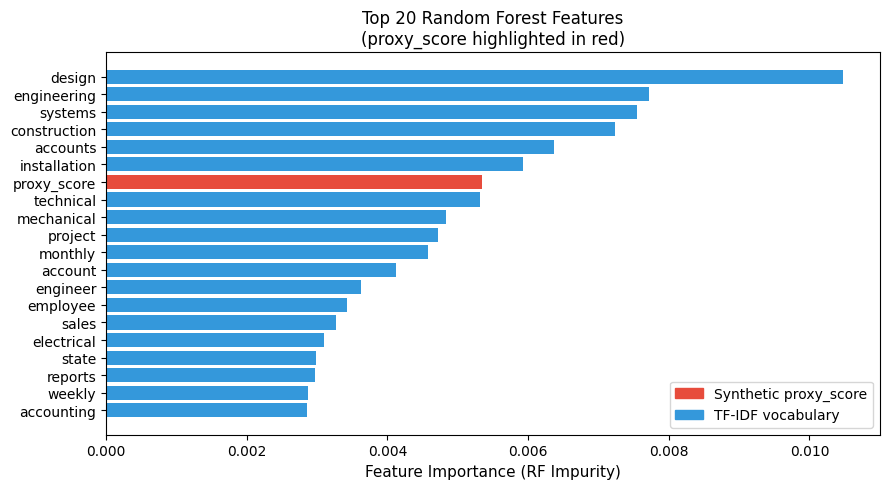

In [49]:
# CELL 8c — Feature Importance Bar Chart (Figure 3 for paper)
fig, ax = plt.subplots(figsize=(9, 5))
names = [f[0] for f in top_features]
vals  = [f[1] for f in top_features]
colors_fi = ["#e74c3c" if n == "proxy_score" else "#3498db" for n in names]

ax.barh(names[::-1], vals[::-1], color=colors_fi[::-1])
ax.set_xlabel("Feature Importance (RF Impurity)", fontsize=11)
ax.set_title("Top 20 Random Forest Features\n(proxy_score highlighted in red)", fontsize=12)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#e74c3c", label="Synthetic proxy_score"),
                   Patch(color="#3498db", label="TF-IDF vocabulary")])
plt.tight_layout()
plt.savefig("figures/feature_importance.png", dpi=150)
plt.show()

In [44]:
# ─────────────────────────────────────────────
# CELL 9 — Bias Mitigation
# ─────────────────────────────────────────────
mitigation_results = {}

# Pre-processing: reweighting
weights = np.where(A_tr == 0, 2.0, 1.0)
lr_pre = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_pre.fit(X_tr, y_tr, sample_weight=weights)
y_pred_pre = lr_pre.predict(X_te)
mitigation_results["LR Reweighting (Pre)"] = {
    "perf": eval_performance(y_te, y_pred_pre, lr_pre.predict_proba(X_te)[:,1]),
    "fair": eval_fairness(y_te, y_pred_pre, A_te),
}
print("Pre-processing done:", mitigation_results["LR Reweighting (Pre)"]["fair"])

# In-processing: ExponentiatedGradient
eg = ExponentiatedGradient(
    LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
    constraints=DemographicParity(), eps=0.01
)
eg.fit(X_tr, y_tr, sensitive_features=A_tr)
y_pred_eg = eg.predict(X_te)
mitigation_results["ExpGrad DP (In)"] = {
    "perf": eval_performance(y_te, y_pred_eg),
    "fair": eval_fairness(y_te, y_pred_eg, A_te),
}
print("In-processing done:", mitigation_results["ExpGrad DP (In)"]["fair"])

# Post-processing: ThresholdOptimizer
base_lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
base_lr.fit(X_tr, y_tr)
topt = ThresholdOptimizer(estimator=base_lr, constraints="demographic_parity",
                          predict_method="predict_proba", objective="accuracy_score")
topt.fit(X_tr, y_tr, sensitive_features=A_tr)
y_pred_to = topt.predict(X_te, sensitive_features=A_te)
mitigation_results["ThresholdOpt (Post)"] = {
    "perf": eval_performance(y_te, y_pred_to),
    "fair": eval_fairness(y_te, y_pred_to, A_te),
}
print("Post-processing done:", mitigation_results["ThresholdOpt (Post)"]["fair"])

Pre-processing done: {'Dem. Parity Diff': np.float64(0.0329), 'Eq. Odds Diff': 0.0914, 'EO (TPR) Diff': np.float64(0.0582), 'TPR (A=0)': np.float64(0.8466), 'TPR (A=1)': np.float64(0.7883), 'Sel Rate (A=0)': np.float64(0.6373), 'Sel Rate (A=1)': np.float64(0.6703)}
In-processing done: {'Dem. Parity Diff': np.float64(0.0325), 'Eq. Odds Diff': 0.1371, 'EO (TPR) Diff': np.float64(0.1274), 'TPR (A=0)': np.float64(0.7989), 'TPR (A=1)': np.float64(0.6715), 'Sel Rate (A=0)': np.float64(0.5947), 'Sel Rate (A=1)': np.float64(0.5622)}
Post-processing done: {'Dem. Parity Diff': np.float64(0.1292), 'Eq. Odds Diff': 0.2424, 'EO (TPR) Diff': np.float64(0.2424), 'TPR (A=0)': np.float64(0.8519), 'TPR (A=1)': np.float64(0.6095), 'Sel Rate (A=0)': np.float64(0.6373), 'Sel Rate (A=1)': np.float64(0.5081)}


In [45]:
# CELL 9b — Understand ThresholdOpt direction
print("Baseline LR:")
print(f"  Sel Rate A=0: {baseline_results['Logistic Regression']['fair']['Sel Rate (A=0)']}")
print(f"  Sel Rate A=1: {baseline_results['Logistic Regression']['fair']['Sel Rate (A=1)']}")
print("\nThresholdOpt:")
print(f"  Sel Rate A=0: {mitigation_results['ThresholdOpt (Post)']['fair']['Sel Rate (A=0)']}")
print(f"  Sel Rate A=1: {mitigation_results['ThresholdOpt (Post)']['fair']['Sel Rate (A=1)']}")

Baseline LR:
  Sel Rate A=0: 0.6373
  Sel Rate A=1: 0.673

ThresholdOpt:
  Sel Rate A=0: 0.6373
  Sel Rate A=1: 0.5081


In [46]:
# ─────────────────────────────────────────────
# CELL 10 — Summary Table
# ─────────────────────────────────────────────
all_results = {**baseline_results, **mitigation_results}
rows = []
for name, res in all_results.items():
    row = {"Model": name}
    row.update({k: round(v,4) for k,v in res["perf"].items()
                if k in ["Accuracy","F1","AUC"]})
    row.update({k: round(abs(v),4) for k,v in res["fair"].items()
                if k in ["Dem. Parity Diff","Eq. Odds Diff"]})
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("Model")
summary_df.to_csv("figures/summary_table.csv")
print(summary_df.to_string())

                      Accuracy      F1     AUC  Dem. Parity Diff  Eq. Odds Diff
Model                                                                          
Logistic Regression     0.7383  0.7950  0.7865            0.0356         0.0860
Random Forest           0.7906  0.8462  0.8423            0.0341         0.1663
LR Reweighting (Pre)    0.7342  0.7916  0.7849            0.0329         0.0914
ExpGrad DP (In)         0.6993  0.7494     NaN            0.0325         0.1371
ThresholdOpt (Post)     0.6859  0.7371     NaN            0.1292         0.2424


In [47]:
# CELL 10b — Proxy Comparison Table
proxy_rows = []
for base_name, proxy_name in [("Logistic Regression","LR (no proxy)"), ("Random Forest","RF (no proxy)")]:
    b = baseline_results[base_name]
    p = proxy_results[proxy_name]
    proxy_rows.append({
        "Model": base_name,
        "DP Diff (with proxy)": round(abs(b["fair"]["Dem. Parity Diff"]), 4),
        "DP Diff (no proxy)":   round(abs(p["fair"]["Dem. Parity Diff"]), 4),
        "EO Diff (with proxy)": round(abs(b["fair"]["Eq. Odds Diff"]), 4),
        "EO Diff (no proxy)":   round(abs(p["fair"]["Eq. Odds Diff"]), 4),
    })
proxy_df = pd.DataFrame(proxy_rows).set_index("Model")
proxy_df.to_csv("figures/proxy_comparison.csv")
print(proxy_df.to_string())

                     DP Diff (with proxy)  DP Diff (no proxy)  EO Diff (with proxy)  EO Diff (no proxy)
Model                                                                                                  
Logistic Regression                0.0356              0.0275                0.0860              0.0964
Random Forest                      0.0341              0.0235                0.1663              0.1882


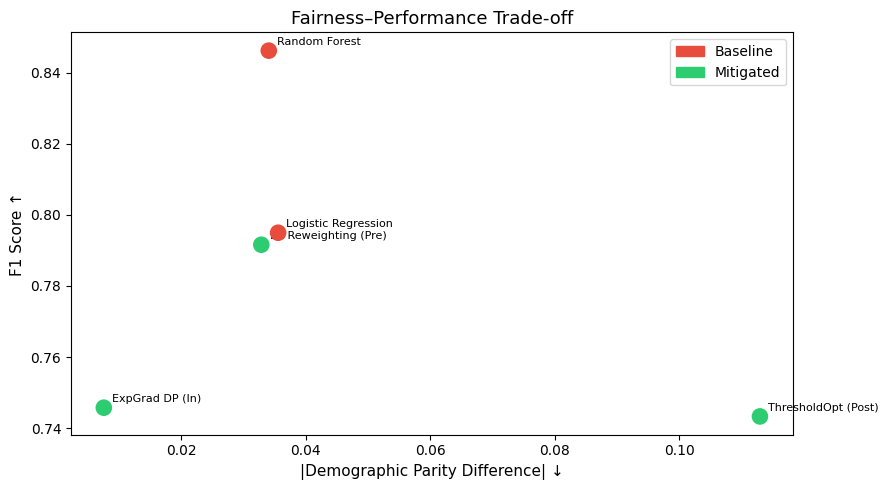

In [34]:
# ─────────────────────────────────────────────
# CELL 11 — Fairness–Performance Trade-off Plot
# ─────────────────────────────────────────────
labels  = list(all_results.keys())
dp_vals = [abs(r["fair"]["Dem. Parity Diff"]) for r in all_results.values()]
f1_vals = [r["perf"]["F1"] for r in all_results.values()]
colors  = (["#e74c3c"] * len(baseline_results)
         + ["#2ecc71"] * len(mitigation_results))

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(dp_vals, f1_vals, c=colors, s=120, zorder=5)
for i, lbl in enumerate(labels):
    ax.annotate(lbl, (dp_vals[i], f1_vals[i]),
                textcoords="offset points", xytext=(6,4), fontsize=8)
ax.set_xlabel("|Demographic Parity Difference| ↓", fontsize=11)
ax.set_ylabel("F1 Score ↑", fontsize=11)
ax.set_title("Fairness–Performance Trade-off", fontsize=13)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#e74c3c", label="Baseline"),
                   Patch(color="#2ecc71", label="Mitigated")])
plt.tight_layout()
plt.savefig("figures/fairness_tradeoff.png", dpi=150)
plt.show()

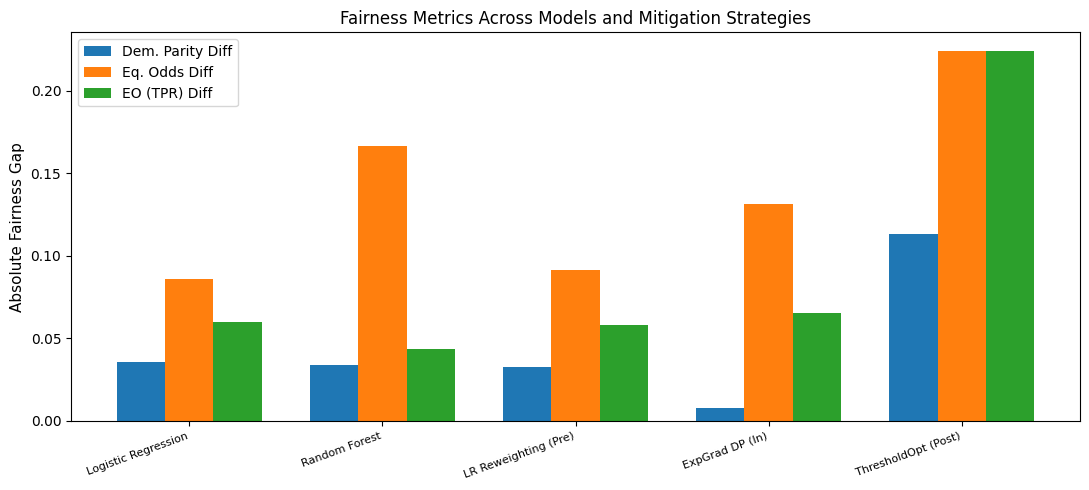

In [35]:
# ─────────────────────────────────────────────
# CELL 12 — Fairness Metrics Bar Chart
# ─────────────────────────────────────────────
metrics  = ["Dem. Parity Diff", "Eq. Odds Diff", "EO (TPR) Diff"]
data     = {m: [abs(r["fair"][m]) for r in all_results.values()] for m in metrics}
x, w     = np.arange(len(all_results)), 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (m, vals) in enumerate(data.items()):
    ax.bar(x + i*w, vals, w, label=m)
ax.set_xticks(x + w)
ax.set_xticklabels(list(all_results.keys()), rotation=20, ha="right", fontsize=8)
ax.set_ylabel("Absolute Fairness Gap", fontsize=11)
ax.set_title("Fairness Metrics Across Models and Mitigation Strategies", fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig("figures/fairness_metrics_bar.png", dpi=150)
plt.show()